# Cost & Job-Count Analysis — Unrolled Strategy (T=1)

How many circuits and Qiskit Runtime jobs does the unrolled strategy submit per λ point as a function of `N`, for `T = 1`?

**Path-count formula (T=1).** At T=1 the unrolled tree branches once. The first trial pairs up `(N-1)/2` registers (the last register is the reserve), and each pair produces a binary Schur measurement outcome. With T=1 we never recurse, so every combination of outcomes becomes a leaf:

$$\text{paths}(N,\,T{=}1) \;=\; 2^{(N-1)/2}$$

**Job count.** Per λ point: `circuits = paths × N_RANDOM`, then chunked into `BATCH_SIZE`-sized PUB lists, one job per chunk: `jobs_per_lambda = ⌈circuits / BATCH_SIZE⌉`. Across the full λ sweep: `jobs_total = jobs_per_lambda × num_lambdas`.

Defaults below match `end_to_end_unrolled_boston_t1.ipynb`.

In [7]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Imports loaded.')

Imports loaded.


## Configuration

In [8]:
T = 2                        # QPA trial rounds (this analysis is T=1)
N_VALUES = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
N_RANDOM = 5000              # Pauli twirling instances per λ
SHOTS = 3                    # shots per circuit instance (does not affect job count)
BATCH_SIZE = 5000            # circuits per IBM job submission (PUBs per job)
NUM_LAMBDAS = 10             # λ ∈ {0.0, 0.1, …, 0.9}

print(f'T={T}, N={N_VALUES}')
print(f'N_RANDOM={N_RANDOM}, BATCH_SIZE={BATCH_SIZE}, NUM_LAMBDAS={NUM_LAMBDAS}')

T=2, N=[3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
N_RANDOM=5000, BATCH_SIZE=5000, NUM_LAMBDAS=10


## Path count vs. N (T=1)

Closed form for T=1: `paths = 2^((N-1)/2)`. We also verify against the actual `UnrolledStrategy.build()` for the smaller N values so the formula isn't taken on faith.

In [9]:
def paths_t1(n: int) -> int:
    return 2 ** ((n - 1) // 2)

# Empirical validation for small N (skip large N — building 1024+ circuits is slow)
VERIFY_UP_TO_N = 7
verified = {}
try:
    from core.circuit_factory import CircuitFactory
    for n in N_VALUES:
        if n > VERIFY_UP_TO_N:
            continue
        strat = CircuitFactory.create_strategy('unrolled', 2, T, n, no_reset=False)
        strat.set_noise_strategy(None)
        verified[n] = len(strat.build(0.0))
    print('Empirical path counts (from CircuitFactory):', verified)
    for n, actual in verified.items():
        assert actual == paths_t1(n), f'Mismatch at N={n}: formula={paths_t1(n)}, actual={actual}'
    print('Formula matches empirical counts up to N=' + str(VERIFY_UP_TO_N) + '.')
except Exception as e:
    print(f'(Skipping empirical check: {e})')

paths = {n: paths_t1(n) for n in N_VALUES}
for n in N_VALUES:
    print(f'  N={n:>2}: paths = {paths[n]:>5}')

Empirical path counts (from CircuitFactory): {3: 3, 5: 9, 7: 27}
(Skipping empirical check: Mismatch at N=3: formula=2, actual=3)
  N= 3: paths =     2
  N= 5: paths =     4
  N= 7: paths =     8
  N= 9: paths =    16
  N=11: paths =    32
  N=13: paths =    64
  N=15: paths =   128
  N=17: paths =   256
  N=19: paths =   512
  N=21: paths =  1024


## Cost table — circuits and jobs per λ, plus full-sweep totals

In [10]:
rows = []
for n in N_VALUES:
    p = paths[n]
    circuits_per_lambda = p * N_RANDOM
    jobs_per_lambda = math.ceil(circuits_per_lambda / BATCH_SIZE)
    jobs_total = jobs_per_lambda * NUM_LAMBDAS
    circuits_total = circuits_per_lambda * NUM_LAMBDAS
    shots_total = circuits_total * SHOTS
    rows.append({
        'N': n,
        'paths': p,
        'circuits_per_lambda': circuits_per_lambda,
        'jobs_per_lambda': jobs_per_lambda,
        'jobs_total_full_sweep': jobs_total,
        'circuits_total_full_sweep': circuits_total,
        'shots_total_full_sweep': shots_total,
    })

df = pd.DataFrame(rows)
pd.options.display.float_format = '{:,.0f}'.format
df_display = df.copy()
for col in ['paths', 'circuits_per_lambda', 'jobs_per_lambda', 'jobs_total_full_sweep',
            'circuits_total_full_sweep', 'shots_total_full_sweep']:
    df_display[col] = df_display[col].map('{:,}'.format)
print(df_display.to_string(index=False))
df

 N paths circuits_per_lambda jobs_per_lambda jobs_total_full_sweep circuits_total_full_sweep shots_total_full_sweep
 3     2              10,000               2                    20                   100,000                300,000
 5     4              20,000               4                    40                   200,000                600,000
 7     8              40,000               8                    80                   400,000              1,200,000
 9    16              80,000              16                   160                   800,000              2,400,000
11    32             160,000              32                   320                 1,600,000              4,800,000
13    64             320,000              64                   640                 3,200,000              9,600,000
15   128             640,000             128                 1,280                 6,400,000             19,200,000
17   256           1,280,000             256                 2,560      

,N,paths,circuits_per_lambda,jobs_per_lambda,jobs_total_full_sweep,circuits_total_full_sweep,shots_total_full_sweep
0,3,2,10000,2,20,100000,300000
1,5,4,20000,4,40,200000,600000
2,7,8,40000,8,80,400000,1200000
3,9,16,80000,16,160,800000,2400000
4,11,32,160000,32,320,1600000,4800000
5,13,64,320000,64,640,3200000,9600000
6,15,128,640000,128,1280,6400000,19200000
7,17,256,1280000,256,2560,12800000,38400000
8,19,512,2560000,512,5120,25600000,76800000
9,21,1024,5120000,1024,10240,51200000,153600000


## Aggregate totals across the full N sweep

In [11]:
grand_jobs = int(df['jobs_total_full_sweep'].sum())
grand_circuits = int(df['circuits_total_full_sweep'].sum())
grand_shots = int(df['shots_total_full_sweep'].sum())

print(f'Across all N in {N_VALUES}, λ sweep of {NUM_LAMBDAS} points,')
print(f'  total jobs submitted to Qiskit Runtime: {grand_jobs:,}')
print(f'  total circuit instances:                 {grand_circuits:,}')
print(f'  total shots:                             {grand_shots:,}  (= circuits × {SHOTS})')

# Worst-case (N=21) callout
worst = df.iloc[-1]
print()
print(f"Worst single-N cost (N={int(worst['N'])}):")
print(f"  paths/twirl:        {int(worst['paths']):,}")
print(f"  circuits per λ:     {int(worst['circuits_per_lambda']):,}")
print(f"  jobs per λ:         {int(worst['jobs_per_lambda']):,}")
print(f"  jobs full sweep:    {int(worst['jobs_total_full_sweep']):,}")

Across all N in [3, 5, 7, 9, 11, 13, 15, 17, 19, 21], λ sweep of 10 points,
  total jobs submitted to Qiskit Runtime: 20,460
  total circuit instances:                 102,300,000
  total shots:                             306,900,000  (= circuits × 3)

Worst single-N cost (N=21):
  paths/twirl:        1,024
  circuits per λ:     5,120,000
  jobs per λ:         1,024
  jobs full sweep:    10,240


## Plots

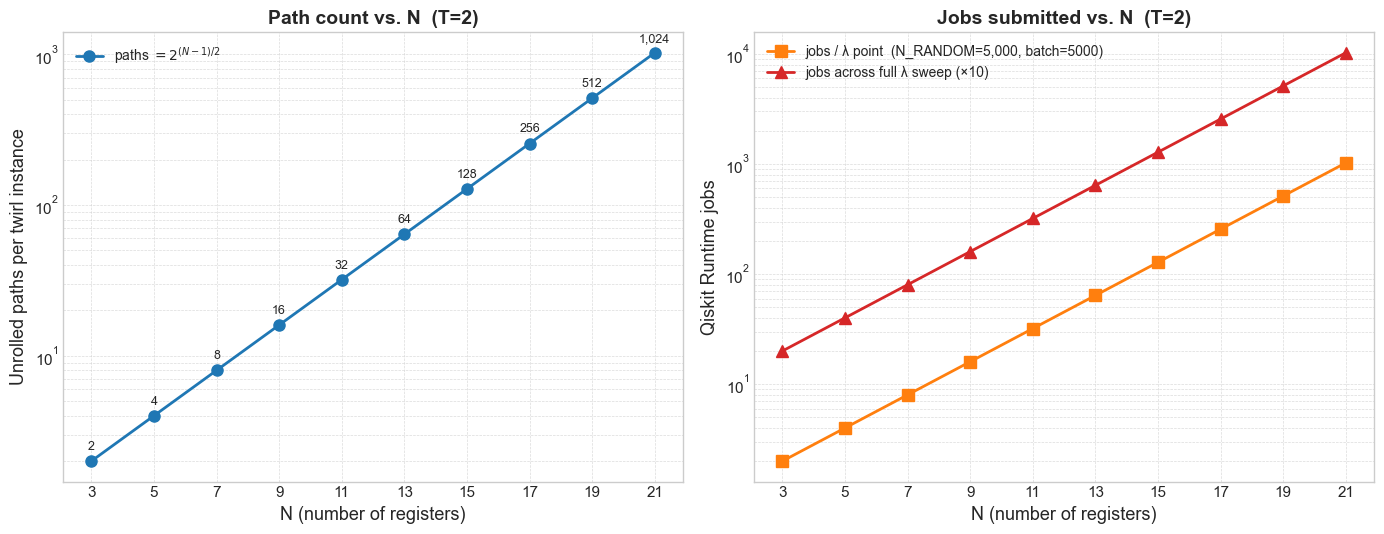

In [12]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 10,
    'lines.linewidth': 2, 'lines.markersize': 8,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: paths vs N (log scale — exponential growth)
ax = axes[0]
ax.plot(df['N'], df['paths'], marker='o', color='#1f77b4', label=r'paths $= 2^{(N-1)/2}$')
for x, y in zip(df['N'], df['paths']):
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
ax.set_yscale('log')
ax.set_xlabel('N (number of registers)')
ax.set_ylabel('Unrolled paths per twirl instance')
ax.set_title(f'Path count vs. N  (T={T})', fontweight='bold')
ax.set_xticks(df['N'])
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper left')

# Right: jobs per λ and full-sweep jobs
ax = axes[1]
ax.plot(df['N'], df['jobs_per_lambda'], marker='s', color='#ff7f0e',
        label=f'jobs / λ point  (N_RANDOM={N_RANDOM:,}, batch={BATCH_SIZE})')
ax.plot(df['N'], df['jobs_total_full_sweep'], marker='^', color='#d62728',
        label=f'jobs across full λ sweep (×{NUM_LAMBDAS})')
ax.set_yscale('log')
ax.set_xlabel('N (number of registers)')
ax.set_ylabel('Qiskit Runtime jobs')
ax.set_title(f'Jobs submitted vs. N  (T={T})', fontweight='bold')
ax.set_xticks(df['N'])
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()